In [2]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
/Users/mahithakalinathabotla/Downloads/Amazon_NLP_Product_Analysis/notebooks


In [14]:
import os

project_path = "/Users/mahithakalinathabotla/Downloads/Amazon_NLP_Product_Analysis"

print("Project contents:")
print(os.listdir(project_path))

Project contents:
['.DS_Store', 'data:raw', '.ipynb_checkpoints', 'notebooks']


In [16]:
import os

for root, dirs, files in os.walk(project_path):
    jsonl_files = [f for f in files if f.endswith(".jsonl")]
    
    if jsonl_files:
        print("\nFolder:", root)
        for f in jsonl_files:
            print("  ", f)


Folder: /Users/mahithakalinathabotla/Downloads/Amazon_NLP_Product_Analysis/data:raw
   meta_Books.jsonl
   meta_Toys_and_Games.jsonl
   meta_Automotive.jsonl
   meta_Electronics.jsonl
   meta_Beauty_and_Personal_Care.jsonl


In [28]:
data_path = "/Users/mahithakalinathabotla/Downloads/Amazon_NLP_Product_Analysis/data"
print("Files found:")
for file in os.listdir(data_path):
    print(file)

Files found:
.DS_Store
meta_Books.jsonl
meta_Toys_and_Games.jsonl
meta_Automotive.jsonl
meta_Electronics.jsonl
meta_Beauty_and_Personal_Care.jsonl


In [30]:
import json

def load_jsonl_sample(filepath, n=5000):
    records = []

    with open(filepath, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= n:
                break

            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    return pd.DataFrame(records)

In [32]:
files = {
    "Electronics": "meta_Electronics.jsonl",
    "Books": "meta_Books.jsonl",
    "Toys & Games": "meta_Toys_and_Games.jsonl",
    "Automotive": "meta_Automotive.jsonl",
    "Beauty & Personal Care": "meta_Beauty_and_Personal_Care.jsonl"
}

In [36]:
import pandas as pd
import numpy as np
import json
import os

In [38]:
def load_jsonl_sample(filepath, n=5000):
    records = []

    with open(filepath, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= n:
                break

            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    return pd.DataFrame(records)

In [40]:
dfs = {}

for category, filename in files.items():

    filepath = os.path.join(data_path, filename)

    print(f"Loading {category}...")

    dfs[category] = load_jsonl_sample(filepath, n=5000)

    print(f"Loaded: {len(dfs[category]):,} products")

Loading Electronics...
Loaded: 5,000 products
Loading Books...
Loaded: 5,000 products
Loading Toys & Games...
Loaded: 5,000 products
Loading Automotive...
Loaded: 5,000 products
Loading Beauty & Personal Care...
Loaded: 5,000 products


In [42]:
dfs["Electronics"].shape

(5000, 16)

In [44]:
dfs["Electronics"].columns.tolist()

['main_category',
 'title',
 'average_rating',
 'rating_number',
 'features',
 'description',
 'price',
 'images',
 'videos',
 'store',
 'categories',
 'details',
 'parent_asin',
 'bought_together',
 'subtitle',
 'author']

In [46]:
dfs["Electronics"].head(2)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Electronics,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6,[],[Teleporter V3 The “Teleporter V3” kit sets a ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Fat Shark,"[Electronics, Television & Video, Video Glasses]","{'Date First Available': 'August 2, 2014', 'Ma...",B00MCW7G9M,None,NaN,NaN
1,All Electronics,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1,"[UPC: 662774021904, Weight: 0.600 lbs]",[HDMI In - HDMI Out],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],SIIG,"[Electronics, Television & Video, Accessories,...",{'Product Dimensions': '0.83 x 4.17 x 2.05 inc...,B00YT6XQSE,None,NaN,NaN


In [48]:
for category, df in dfs.items():
    print(f"\n{category}")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())


Electronics
Shape: (5000, 16)
Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']

Books
Shape: (5000, 16)
Columns: ['main_category', 'title', 'subtitle', 'author', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']

Toys & Games
Shape: (5000, 16)
Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']

Automotive
Shape: (5000, 16)
Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']

Beauty & Pers

In [50]:
dfs["Electronics"].isnull().sum()

main_category        53
title                 0
average_rating        0
rating_number         0
features              0
description           0
price              2862
images                0
videos                0
store                35
categories            0
details               0
parent_asin           0
bought_together    5000
subtitle           4997
author             4998
dtype: int64

In [52]:
combined_dfs = []

for category, df in dfs.items():
    temp = df.copy()
    temp["target_category"] = category
    combined_dfs.append(temp)

amazon_df = pd.concat(combined_dfs, ignore_index=True)

print("Total products:", len(amazon_df))
print("Columns:", amazon_df.columns.tolist())

Total products: 25000
Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author', 'target_category']


In [54]:
amazon_df["target_category"].value_counts()

target_category
Electronics               5000
Books                     5000
Toys & Games              5000
Automotive                5000
Beauty & Personal Care    5000
Name: count, dtype: int64

In [56]:
text_columns = [
    "title",
    "features",
    "description"
]

amazon_df = amazon_df[
    text_columns + ["target_category"]
].copy()

amazon_df.head(2)

,title,features,description,target_category
0,FS-1051 FATSHARK TELEPORTER V3 HEADSET,[],[Teleporter V3 The “Teleporter V3” kit sets a ...,Electronics
1,Ce-H22B12-S1 4Kx2K Hdmi 4Port,"[UPC: 662774021904, Weight: 0.600 lbs]",[HDMI In - HDMI Out],Electronics


In [58]:
amazon_df.isnull().sum()

title              0
features           0
description        0
target_category    0
dtype: int64

In [60]:
["HDMI Input", "HDMI Output" "4 Port"]

['HDMI Input', 'HDMI Output', '4 Port']

In [62]:
def convert_to_text(value):
    if isinstance(value, list):
        return " ".join(str(item) for item in value)
    
    if pd.isna(value):
        return ""
    
    return str(value)

In [68]:
for column in ["title", "features", "description"]:
    amazon_df[column] = amazon_df[column].apply(convert_to_text)
    amazon_df["combined_text"] = (
    amazon_df["title"] + " " +
    amazon_df["features"] + " " +
    amazon_df["description"]
)

In [70]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    
    # Keep only alphabetic/numeric characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    
    # Tokenization
    tokens = text.split()
    
    # Remove stopwords and stem
    tokens = [
        stemmer.stem(word)
        for word in tokens
        if word not in stop_words
    ]
    
    return " ".join(tokens)

amazon_df["processed_text"] = amazon_df["combined_text"].apply(preprocess_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mahithakalinathabotla/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [72]:
amazon_df[["combined_text", "processed_text", "target_category"]].head()

,combined_text,processed_text,target_category
0,FS-1051 FATSHARK TELEPORTER V3 HEADSET Telepo...,fs 1051 fatshark teleport v3 headset teleport ...,Electronics
1,Ce-H22B12-S1 4Kx2K Hdmi 4Port UPC: 66277402190...,ce h22b12 s1 4kx2k hdmi 4port upc 662774021904...,Electronics
2,Digi-Tatoo Decal Skin Compatible With MacBook ...,digi tatoo decal skin compat macbook pro 13 in...,Electronics
3,NotoCity Compatible with Vivoactive 4 band 22m...,notoc compat vivoact 4 band 22mm quick releas ...,Electronics
4,Motorola Droid X Essentials Combo Pack New Dro...,motorola droid x essenti combo pack new droid ...,Electronics


In [74]:
from sklearn.model_selection import train_test_split

X = amazon_df["processed_text"]
y = amazon_df["target_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 20000
Testing samples: 5000


In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (20000, 20000)
Testing TF-IDF shape: (5000, 20000)


In [81]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred = nb_model.predict(X_test_tfidf)

In [83]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.943

Classification Report:
                        precision    recall  f1-score   support

            Automotive       0.91      0.96      0.93      1000
Beauty & Personal Care       0.97      0.98      0.98      1000
                 Books       0.97      0.96      0.96      1000
           Electronics       0.93      0.94      0.94      1000
          Toys & Games       0.93      0.89      0.91      1000

              accuracy                           0.94      5000
             macro avg       0.94      0.94      0.94      5000
          weighted avg       0.94      0.94      0.94      5000



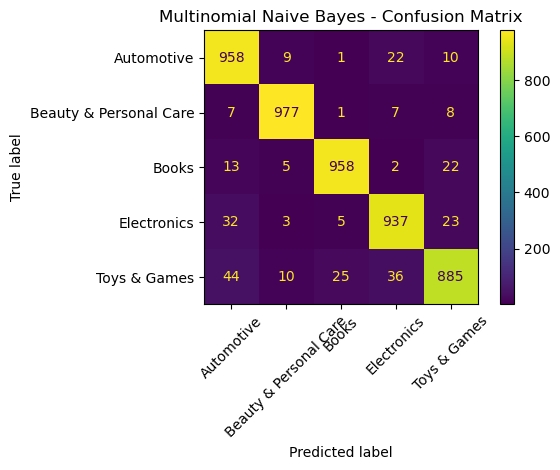

In [85]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Multinomial Naive Bayes - Confusion Matrix")
plt.tight_layout()
plt.show()

In [87]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    tfidf.transform(amazon_df["processed_text"])
)

amazon_df["cluster"] = cluster_labels

In [89]:
pd.crosstab(
    amazon_df["cluster"],
    amazon_df["target_category"]
)

target_category,Automotive,Beauty & Personal Care,Books,Electronics,Toys & Games
cluster,,,,,
0,0,1,3904,5,42
1,1,1313,0,0,6
2,0,480,0,0,0
3,486,3052,1030,344,4333
4,4513,154,66,4651,619


In [91]:
import numpy as np

terms = tfidf.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for cluster_num in range(5):
    top_terms = [
        terms[ind]
        for ind in order_centroids[cluster_num, :10]
    ]
    
    print(f"Cluster {cluster_num}:")
    print(", ".join(top_terms))
    print()

Cluster 0:
book, author, stori, life, world, new, one, live, read, time

Cluster 1:
hair, wig, human hair, clip, extens, color, hair extens, human, natur, lace

Cluster 2:
nail, polish, gel, nail art, nail polish, art, gel nail, manicur, acryl, color

Cluster 3:
skin, toy, parti, color, kid, gift, card, puzzl, game, set

Cluster 4:
fit, car, case, compat, cabl, replac, design, protect, usb, light



In [93]:
from sklearn.metrics.pairwise import cosine_similarity

product_vectors = tfidf.transform(
    amazon_df["processed_text"]
)

In [95]:
def search_products(query, top_n=5):
    
    query_processed = preprocess_text(query)
    
    query_vector = tfidf.transform([query_processed])
    
    similarities = cosine_similarity(
        query_vector,
        product_vectors
    ).flatten()
    
    top_indices = similarities.argsort()[-top_n:][::-1]
    
    results = amazon_df.iloc[top_indices].copy()
    results["similarity_score"] = similarities[top_indices]
    
    return results[
        ["title", "target_category", "similarity_score"]
    ]

In [97]:
search_products(
    "wireless headphones with bluetooth",
    top_n=5
)

,title,target_category,similarity_score
3553,"Bluetooth Headphones, PowerLocus Bluetooth Hea...",Electronics,0.544604
1476,"Wireless Earbuds Bluetooth Headphones, A8 Game...",Electronics,0.541394
3440,Replacement USB Charging Charger Power Supply ...,Electronics,0.535453
3229,ZKAPOR Open Ear Headphones Sports Bluetooth Ea...,Electronics,0.442704
787,"Manhattan 178709 Wireless Heaphones, Black",Electronics,0.427981


In [99]:
search_products(
    "car replacement parts",
    top_n=5
)

,title,target_category,similarity_score
16312,Scandvik 10031 White Cup Replacement Part,Automotive,0.437647
18453,Genuine Toyota Parts 76083-02010-C1 Front Bump...,Automotive,0.402974
14139,LAEGENDARY 1:16 Scale RC Cars Replacement Part...,Toys & Games,0.394759
17599,Genuine GM Parts 15758519 Driver Side Pickup B...,Automotive,0.390365
10263,TEAM LOSI RACING 10 x 14mm Shims 0.1mm and 0.2...,Toys & Games,0.380070


In [101]:
search_products(
    "children's educational games",
    top_n=5
)

,title,target_category,similarity_score
9722,Taxonomy of Educational Objectives: The Classi...,Books,0.410432
9684,Seducing Souls: Education and the Experience o...,Books,0.359445
9589,Web 2.0: How-To for Educators,Books,0.335029
10625,Video Game FX Pocket Pinball Game with Authent...,Toys & Games,0.331672
9065,Accredited Institutions of Postsecondary Educa...,Books,0.325976


In [103]:
from sklearn.metrics import silhouette_score

X_cluster = tfidf.transform(amazon_df["processed_text"])

silhouette = silhouette_score(
    X_cluster,
    amazon_df["cluster"],
    sample_size=5000,
    random_state=42
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.010035855378258497


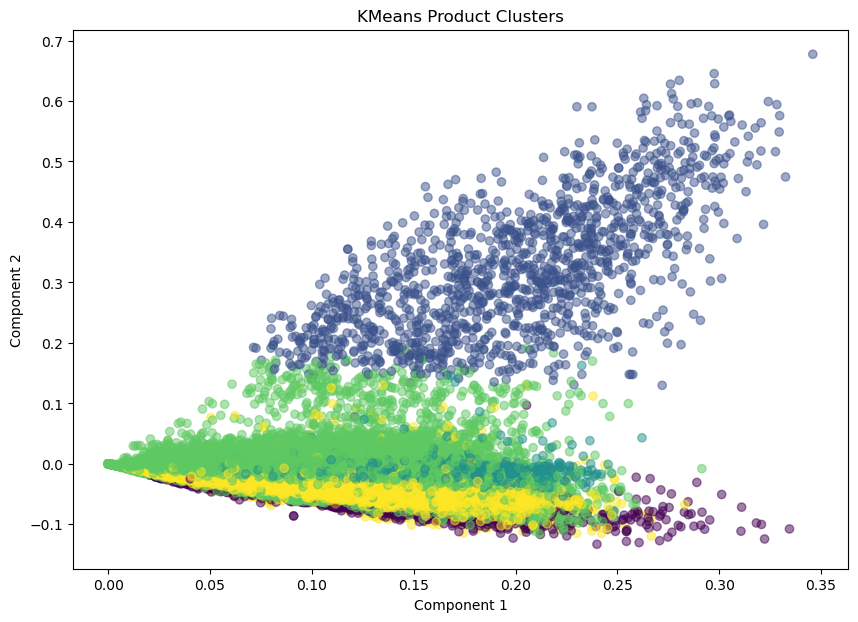

In [105]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

svd = TruncatedSVD(n_components=2, random_state=42)

X_2d = svd.fit_transform(
    tfidf.transform(amazon_df["processed_text"])
)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=amazon_df["cluster"],
    alpha=0.5
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("KMeans Product Clusters")
plt.show()

In [107]:
from sklearn.metrics import silhouette_score

X_cluster = tfidf.transform(amazon_df["processed_text"])

silhouette = silhouette_score(
    X_cluster,
    amazon_df["cluster"],
    sample_size=5000,
    random_state=42
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.010035855378258497


In [109]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_cluster = tfidf.transform(amazon_df["processed_text"])

scores = {}

for k in range(2, 11):
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans_test.fit_predict(X_cluster)
    
    score = silhouette_score(
        X_cluster,
        labels,
        sample_size=5000,
        random_state=42
    )
    
    scores[k] = score
    
    print(f"k={k}: Silhouette Score={score:.4f}")

k=2: Silhouette Score=0.0047
k=3: Silhouette Score=0.0062
k=4: Silhouette Score=0.0085
k=5: Silhouette Score=0.0100
k=6: Silhouette Score=0.0107
k=7: Silhouette Score=0.0119
k=8: Silhouette Score=0.0127
k=9: Silhouette Score=0.0129
k=10: Silhouette Score=0.0131


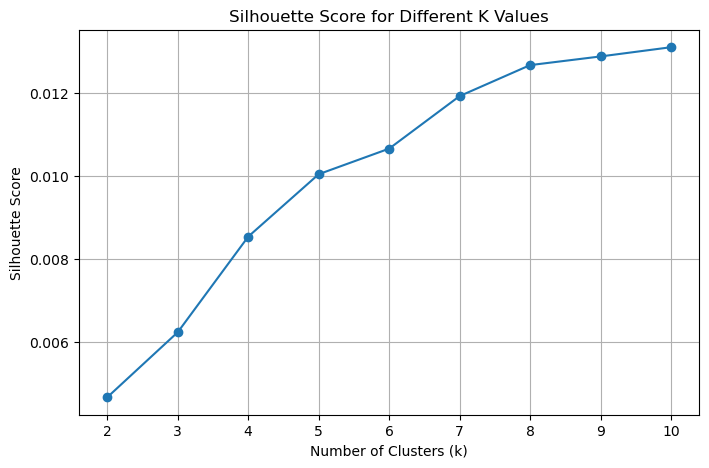

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    list(scores.keys()),
    list(scores.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [113]:
results = pd.DataFrame({
    "Component": [
        "Naive Bayes Classification",
        "KMeans Clustering (k=5)",
        "Semantic Search"
    ],
    "Method": [
        "TF-IDF + MultinomialNB",
        "TF-IDF + KMeans",
        "TF-IDF + Cosine Similarity"
    ],
    "Result": [
        "94.3% Accuracy",
        "Silhouette = 0.010",
        "Relevant top-5 retrieval"
    ]
})

results

,Component,Method,Result
0,Naive Bayes Classification,TF-IDF + MultinomialNB,94.3% Accuracy
1,KMeans Clustering (k=5),TF-IDF + KMeans,Silhouette = 0.010
2,Semantic Search,TF-IDF + Cosine Similarity,Relevant top-5 retrieval
